# STROKE PREDICTION (ML PROJECT)

## LIBARARIES AND TOOLS 

### CORE LIBRARIES

In [64]:
import numpy as np
import pandas as pd

#VISUALIZATION
#------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Data Splitting
# -------------------------
from sklearn.model_selection import train_test_split

# -------------------------
# Preprocessing
# ------------------------
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# -------------------------
# Common Imports
# -------------------------
from sklearn.pipeline import Pipeline
#---------------------------
# Models
# ---------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


# Handling Imbalanced Data
# ---------------------------------
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# ----------------------------------
# Evaluation Metrics
# --------------------------------
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

# -------------------------------
# Model Tuning & Validation
# -------------------------------
from sklearn.model_selection import GridSearchCV

# ------------------------------
# Model Save
# -----------------------------
import joblib

In [65]:
df=pd.read_csv("D:/ml project/healthcare-dataset-stroke-data.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [66]:
print(":GENDER TYPE\n")
print(df["gender"].unique())

print("__________________________________")
print(":WORK TYPE\n")
print(df["work_type"].unique())

print("__________________________________")

print(":RESIDENCE TYPE\n")
print(df["Residence_type"].unique())

print("__________________________________")

print("\nSMOKING STATUS:\n")
print(df["smoking_status"].unique())

:GENDER TYPE

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
__________________________________
:WORK TYPE

<ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
__________________________________
:RESIDENCE TYPE

<ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str
__________________________________

SMOKING STATUS:

<ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


## DATA UNDERSTANDING

In [67]:
print("Column DataTypes:_\n",df.dtypes)

Column DataTypes:_
 id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object


In [68]:
print("Dataframe size:-",df.size)     #total amount of data

Dataframe size:- 61320


In [69]:
print("Dataframe Shape:-",df.shape)     #total no of rows and columns

Dataframe Shape:- (5110, 12)


In [70]:
print("Column Names:-\n",df.columns)    #column names

Column Names:-
 Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [71]:
print("Statistical Summary:-\n")
df.describe()


Statistical Summary:-



,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [72]:
print("Total NULL Values in Each Column=\n",df.isnull().sum())

Total NULL Values in Each Column=
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [73]:
df["bmi"]=df["bmi"].fillna(df["bmi"].mean())

In [74]:
# drop un necessary data
df = df.drop("id",axis=1)

In [75]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [76]:
# TARGET VARIABLE ANALYSIS

print("Total Count Of stroke :-")
df["stroke"].value_counts()

Total Count Of stroke :-


stroke
0    4861
1     249
Name: count, dtype: int64

## EXPLORATARY DATA ANALYSIS(EDA)

In [77]:
# categorical features analysis
cols = df.select_dtypes(include='object').columns
cols

C:\Users\SHIMNA\AppData\Local\Temp\ipykernel_21472\632882516.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include='object').columns


Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

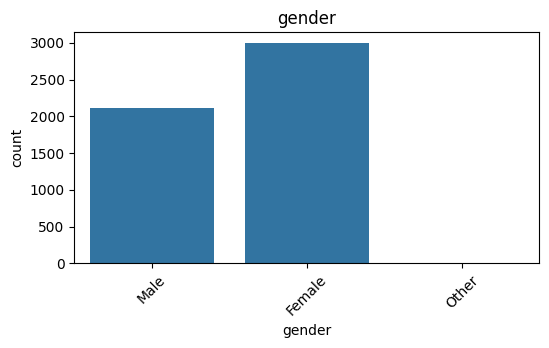

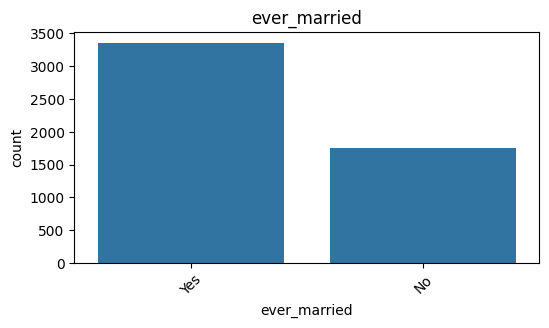

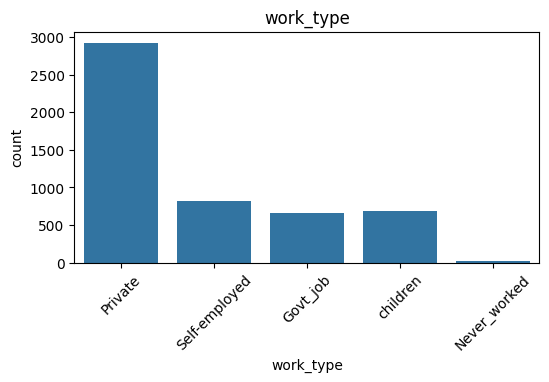

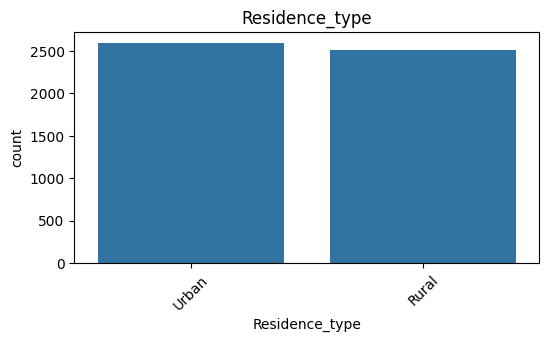

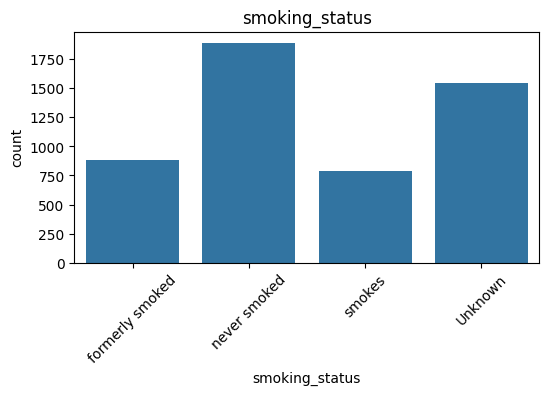

In [78]:
for col in cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

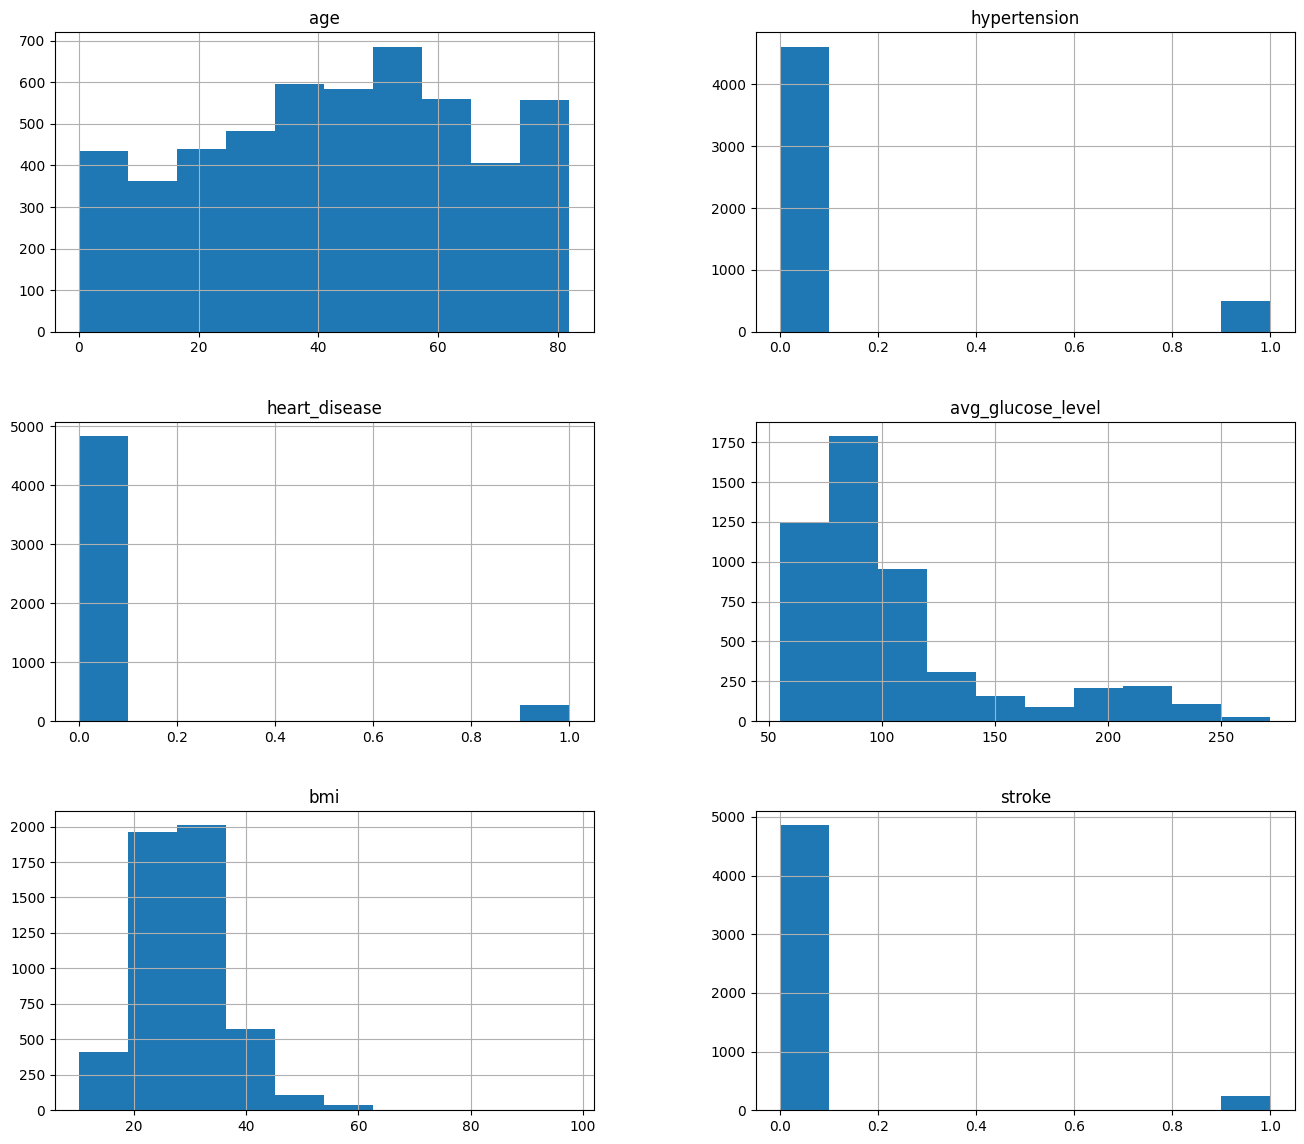

In [79]:
# NUMERICAL FEATURES ANALYSIS( HISTOGRAM )

num_cols = df.select_dtypes(include=["float64","int64"]).columns
num_cols

# histogram
df[num_cols].hist(figsize=(16,14))
plt.show()

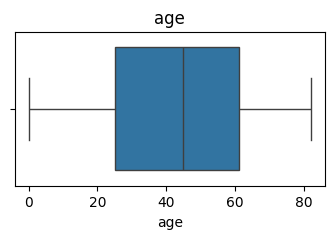

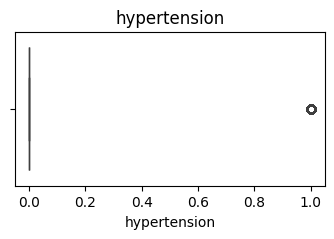

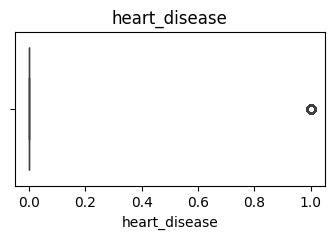

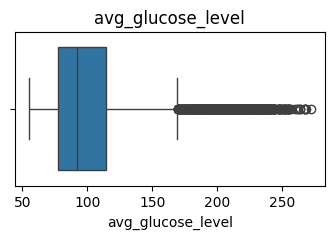

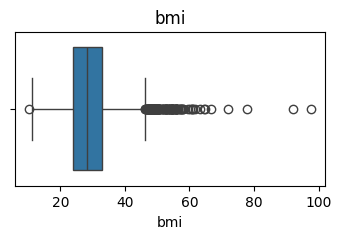

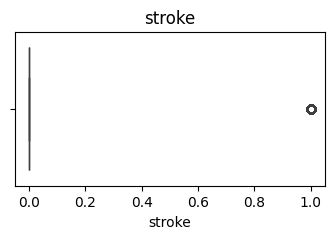

In [17]:
### box plot (for outlier detection)

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'age'),
  Text(1, 0, 'hypertension'),
  Text(2, 0, 'heart_disease'),
  Text(3, 0, 'avg_glucose_level'),
  Text(4, 0, 'bmi'),
  Text(5, 0, 'stroke')])

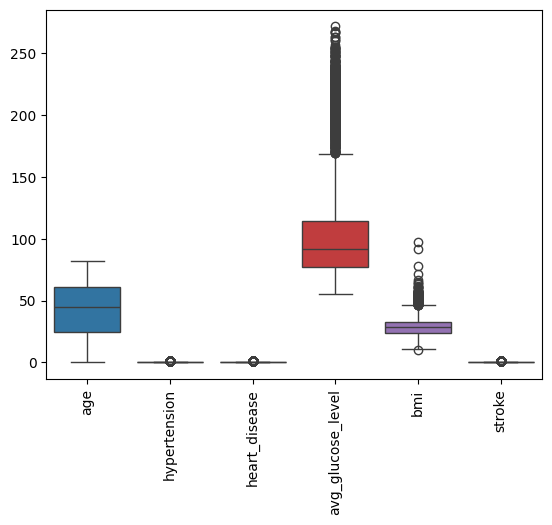

In [18]:
sns.boxplot(df)
plt.xticks(rotation=90)

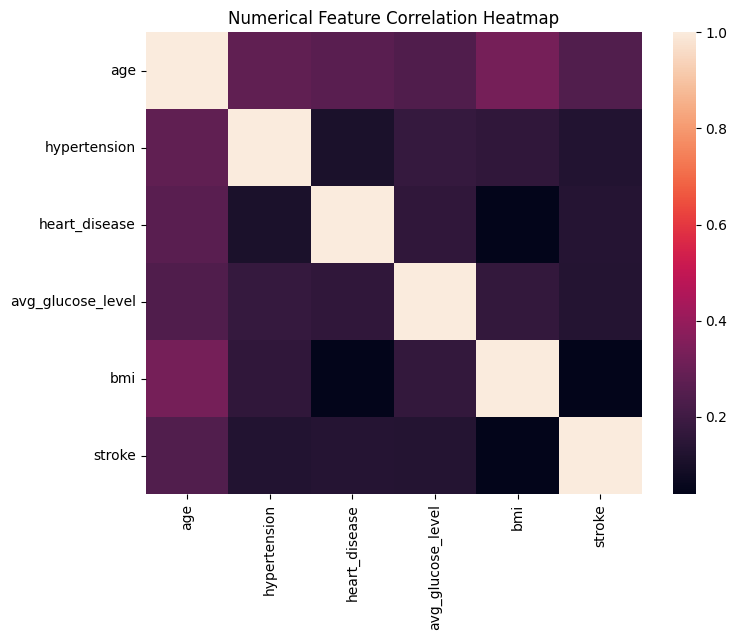

In [19]:
# CORRELATION ANALYSIS ( HEATMAP ) before outlier remove 

corr = df.select_dtypes(include=["float64","int64"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr)
plt.title("Numerical Feature Correlation Heatmap")
plt.show()

## Remove outliers(IQR method)

In [20]:
# remove avg_gulcose level
Q1=df["avg_glucose_level"].quantile(0.25)
Q3=df["avg_glucose_level"].quantile(0.75)
IQR=Q3-Q1       

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df_clean1=df[(df["avg_glucose_level"]>=lower)&(df["avg_glucose_level"]<=upper)]
print("before",df.shape)
print("after",df_clean1.shape)


before (5110, 11)
after (4483, 11)


In [21]:
# remove BMI
Q1=df["bmi"].quantile(0.25)
Q3=df["bmi"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df_clean=df[(df["bmi"]>=lower)&(df["bmi"]<=upper)]
print("before",df.shape)
print("after",df_clean.shape)

before (5110, 11)
after (4984, 11)


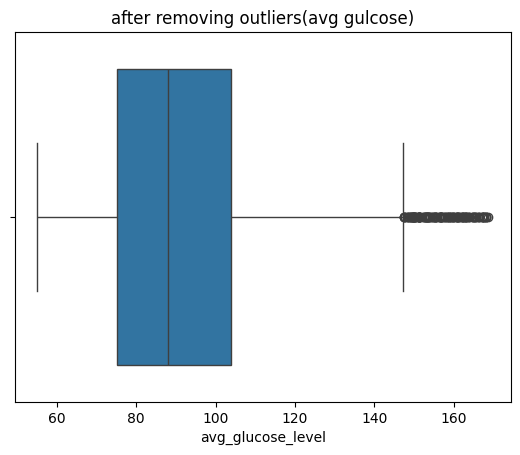

In [22]:
# after remove  outlier(visualizaton)
sns.boxplot(x=df_clean1["avg_glucose_level"])
plt.title("after removing outliers(avg gulcose)")
plt.show()

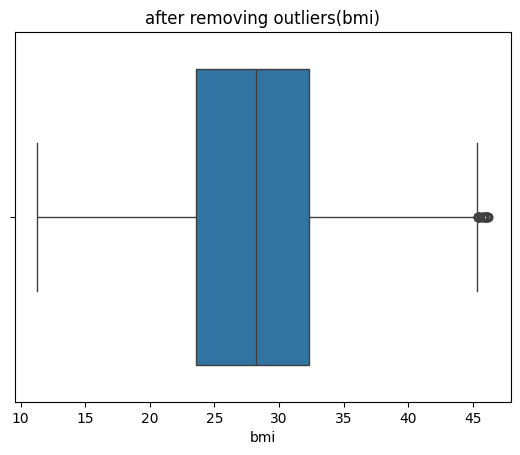

In [23]:
# after remove  outlier(visualizaton)
sns.boxplot(x=df_clean["bmi"])
plt.title("after removing outliers(bmi)")
plt.show()

### convert categorical data

In [24]:
le_gender=LabelEncoder()
le_ever_married=LabelEncoder()
le_work_type=LabelEncoder()
le_Residence_type=LabelEncoder()
le_smoking_status=LabelEncoder()

df["gender_n"]=le_gender.fit_transform(df["gender"])
df["ever_married_n"]=le_ever_married.fit_transform(df["ever_married"])
df["work_type_n"]=le_work_type.fit_transform(df["work_type"])
df["Residence_type_n"]=le_Residence_type.fit_transform(df["Residence_type"])
df["smoking_status_n"]=le_smoking_status.fit_transform(df["smoking_status"])


df_encoded=df[["gender_n","ever_married_n","work_type_n","Residence_type_n","smoking_status_n"]]
df_encoded

,gender_n,ever_married_n,work_type_n,Residence_type_n,smoking_status_n
0,1,1,2,1,1
1,0,1,3,0,2
2,1,1,2,0,2
3,0,1,2,1,3
4,0,1,3,0,2
...,...,...,...,...,...
5105,0,1,2,1,2
5106,0,1,3,1,2
5107,0,1,3,0,2
5108,1,1,2,0,1


In [25]:
df.dtypes

gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
gender_n               int64
ever_married_n         int64
work_type_n            int64
Residence_type_n       int64
smoking_status_n       int64
dtype: object

In [26]:
le=LabelEncoder()
categorical_cols=df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

C:\Users\SHIMNA\AppData\Local\Temp\ipykernel_21472\1931499788.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=df.select_dtypes(include="object").columns


In [27]:
df.dtypes

gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
gender_n               int64
ever_married_n         int64
work_type_n            int64
Residence_type_n       int64
smoking_status_n       int64
dtype: object

### split features

In [28]:
x=df.drop("stroke",axis=1)
y=df["stroke"]  #target

### Train Test Split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Column sepration

In [30]:
categorical_cols = x.select_dtypes(include="object").columns
numerical_cols = x.select_dtypes(include=["int64", "float64"]).columns
# categorical_cols
# numerical_cols

### preprocessor

In [31]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

In [32]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
gender_n             0
ever_married_n       0
work_type_n          0
Residence_type_n     0
smoking_status_n     0
dtype: int64

## CLASSIFICATION MODEL

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

## train and evaluate models(before SMOTE)

In [34]:
results_before={}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    results_before[name]=acc

    print("Model:",name)
    print("Accuracy:",acc)
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("_________________________________________________________________")

Model: Logistic Regression
Accuracy: 0.9393346379647749
Confusion Matrix:
 [[960   0]
 [ 62   0]]
Model: Decision Tree
Accuracy: 0.9070450097847358
Confusion Matrix:
 [[918  42]
 [ 53   9]]
Model: KNN
Accuracy: 0.9315068493150684
Confusion Matrix:
 [[952   8]
 [ 62   0]]
Model: SVM
Accuracy: 0.9393346379647749
Confusion Matrix:
 [[960   0]
 [ 62   0]]
Model: Random Forest
Accuracy: 0.9383561643835616
Confusion Matrix:
 [[959   1]
 [ 62   0]]
Model: AdaBoost
Accuracy: 0.9393346379647749
Confusion Matrix:
 [[960   0]
 [ 62   0]]
Model: Gradient Boosting
Accuracy: 0.9393346379647749
Confusion Matrix:
 [[959   1]
 [ 61   1]]
Model: XGBoost
Accuracy: 0.9373776908023483
Confusion Matrix:
 [[953   7]
 [ 57   5]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.42      0.08      0.14        62

    accuracy                           0.94      1022
   macro avg       0.68      0.54      0.55

## show accuracy table

In [35]:
accuracy_table=pd.DataFrame(list(results_before.items()),
columns=["model","accuracy"])
print(accuracy_table)

                 model  accuracy
0  Logistic Regression  0.939335
1        Decision Tree  0.907045
2                  KNN  0.931507
3                  SVM  0.939335
4        Random Forest  0.938356
5             AdaBoost  0.939335
6    Gradient Boosting  0.939335
7              XGBoost  0.937378


## Apply smote

In [36]:
smote= SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

## Train and evalute models ( After Smote)

In [37]:
!pip install -U scikit-learn imbalanced-learn

In [38]:
results_after={}
for name,model in models.items():
    model.fit(x_train_smote,y_train_smote)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    results_after[name]=acc

    print("Model:",name)
    print("Accuracy:",acc)
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("_________________________________________________________________")

Model: Logistic Regression
Accuracy: 0.7818003913894325
Confusion Matrix:
 [[761 199]
 [ 24  38]]
Model: Decision Tree
Accuracy: 0.8688845401174168
Confusion Matrix:
 [[872  88]
 [ 46  16]]
Model: KNN
Accuracy: 0.7984344422700587
Confusion Matrix:
 [[781 179]
 [ 27  35]]
Model: SVM
Accuracy: 0.7289628180039139
Confusion Matrix:
 [[699 261]
 [ 16  46]]
Model: Random Forest
Accuracy: 0.8913894324853229
Confusion Matrix:
 [[901  59]
 [ 52  10]]
Model: AdaBoost
Accuracy: 0.7524461839530333
Confusion Matrix:
 [[729 231]
 [ 22  40]]
Model: Gradient Boosting
Accuracy: 0.8307240704500979
Confusion Matrix:
 [[822 138]
 [ 35  27]]
Model: XGBoost
Accuracy: 0.8992172211350293
Confusion Matrix:
 [[908  52]
 [ 51  11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       960
           1       0.17      0.18      0.18        62

    accuracy                           0.90      1022
   macro avg       0.56      0.56      0.56

In [39]:
print(results_after)

{'Logistic Regression': 0.7818003913894325, 'Decision Tree': 0.8688845401174168, 'KNN': 0.7984344422700587, 'SVM': 0.7289628180039139, 'Random Forest': 0.8913894324853229, 'AdaBoost': 0.7524461839530333, 'Gradient Boosting': 0.8307240704500979, 'XGBoost': 0.8992172211350293}


### comparison table(accuracy table before and after)

In [40]:
comparison=pd.DataFrame({
    "Before_SMOTE":results_before,
    "After_SMOTE":results_after})
print(comparison)

                     Before_SMOTE  After_SMOTE
Logistic Regression      0.939335     0.781800
Decision Tree            0.907045     0.868885
KNN                      0.931507     0.798434
SVM                      0.939335     0.728963
Random Forest            0.938356     0.891389
AdaBoost                 0.939335     0.752446
Gradient Boosting        0.939335     0.830724
XGBoost                  0.937378     0.899217


### plot Accuracy Comparison Graph

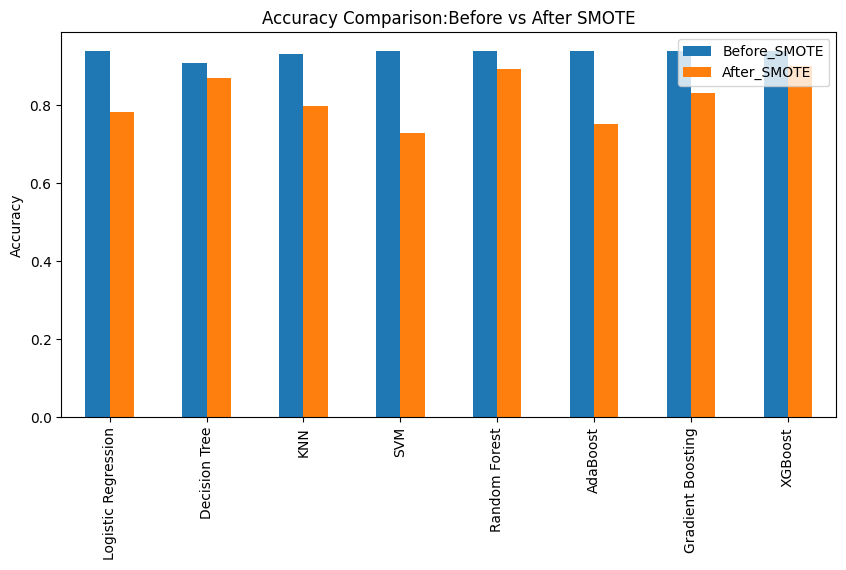

In [41]:
comparison.plot(kind="bar",figsize=(10,5))
plt.title("Accuracy Comparison:Before vs After SMOTE")
plt.ylabel("Accuracy")
plt.show()

## ROC-AUC Calculation before SMOTE

In [42]:
before_smote=[]
for name,model in models.items():
    model.fit(x_train,y_train)
    y_prob=model.predict_proba(x_test)[:,1]
    auc=roc_auc_score(y_test,y_prob)
    
    before_smote.append({"Model":name,"ROC_AUC_Before_SMOTE":auc})
    before_df=pd.DataFrame(before_smote)
before_df

,Model,ROC_AUC_Before_SMOTE
0,Logistic Regression,0.851277
1,Decision Tree,0.550706
2,KNN,0.660694
3,SVM,0.654872
4,Random Forest,0.801151
5,AdaBoost,0.838743
6,Gradient Boosting,0.835517
7,XGBoost,0.786912


## ROC-AUC Calculation After SMOTE

In [43]:
after_smote=[]
for name,model in models.items():
    model.fit(x_train_smote,y_train_smote)
    y_prob=model.predict_proba(x_test)[:,1]
    auc=roc_auc_score(y_test,y_prob)
    
    after_smote.append({"Model":name,"ROC_AUC_After_SMOTE":auc})
    after_df=pd.DataFrame(after_smote)
after_df

,Model,ROC_AUC_After_SMOTE
0,Logistic Regression,0.777403
1,Decision Tree,0.583199
2,KNN,0.745430
3,SVM,0.837298
4,Random Forest,0.761820
5,AdaBoost,0.809123
6,Gradient Boosting,0.770766
7,XGBoost,0.753545


# HYPERPARAMEATER TUNING( for all classifier)

## Hyperparameater tuning with smote

In [44]:
param_grids = {
    "Logistic Regression": {"model__C": [0.1, 1, 10]},
    "Decision Tree": {"model__max_depth": [None, 10, 20]},
    "KNN": {"model__n_neighbors": [3,5,7]},
    "SVM": {"model__C": [0.1,1,10]},
    "Random Forest": {"model__n_estimators": [100,200]},
    "AdaBoost": {"model__n_estimators": [50,100]},
    "Gradient Boosting": {"model__n_estimators": [100,200]},
    "XGBoost": {"model__n_estimators": [100,200]}
}

tuned_results = []

for name, model in models.items():
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    
    grid = GridSearchCV(pipe, param_grids[name], scoring="recall", cv=5, n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    
    y_prob = grid.best_estimator_.predict_proba(x_test)[:,1];
    
    tuned_results.append({
        "Model": name,
        "ROC_AUC_Tuned": roc_auc_score(y_test, y_prob)
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df


,Model,ROC_AUC_Tuned
0,Logistic Regression,0.849513
1,Decision Tree,0.661055
2,KNN,0.714449
3,SVM,0.807846
4,Random Forest,0.800252
5,AdaBoost,0.841146
6,Gradient Boosting,0.820758
7,XGBoost,0.779385


In [45]:
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[924  36]
 [ 59   3]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.08      0.05      0.06        62

    accuracy                           0.91      1022
   macro avg       0.51      0.51      0.51      1022
weighted avg       0.89      0.91      0.90      1022

ROC-AUC: 0.7793850806451613


## FINAL MODEL COMPARISION

In [46]:
final_df=before_df.merge(after_df,on="Model")
final_df=final_df.merge(tuned_df,on="Model")
final_df

,Model,ROC_AUC_Before_SMOTE,ROC_AUC_After_SMOTE,ROC_AUC_Tuned
0,Logistic Regression,0.851277,0.777403,0.849513
1,Decision Tree,0.550706,0.583199,0.661055
2,KNN,0.660694,0.745430,0.714449
3,SVM,0.654872,0.837298,0.807846
4,Random Forest,0.801151,0.761820,0.800252
5,AdaBoost,0.838743,0.809123,0.841146
6,Gradient Boosting,0.835517,0.770766,0.820758
7,XGBoost,0.786912,0.753545,0.779385


## MODEL SAVE

In [47]:
#fit  processor
preprocessor.fit(x_train)
# Transform
x_train_processed=preprocessor.transform(x_train)
x_test_processed=preprocessor.transform(x_test)

In [48]:
model.fit(x_train_processed,y_train)

joblib.dump(model,"strock_prediction_model.pkl")

['strock_prediction_model.pkl']